<a href="https://colab.research.google.com/github/Juanma-dev-tech/aprendizaje-automatico-1/blob/main/TP5/TP5_AA1_clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 AA1 Clasificación

**Juan Manuel Yñiguez**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2) No pueden repetir el mismo dataset que ya haya definido un compañero.

3) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

4) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

5) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

6) Revise las fecha límite de entrega de este trabajo

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

###Dataset elegido: Bank Marketing


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - Describan si observan o no relaciones entre algunas variables.  


## Resolución:

In [192]:
!pip install ucimlrepo

In [193]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

df = pd.concat([X, y], axis=1)

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


El dataset Bank Marketing contiene 45.211 registros y 17 variables. Se identificaron 7 variables numéricas y 10 variables categóricas. La variable objetivo es y, que indica si el cliente aceptó o no una campaña de marketing para contratar un depósito a plazo fijo. Dado que la variable objetivo posee dos posibles valores (yes/no), se trata de un problema de **clasificación binaria**.


In [195]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


Se detectaron valores faltantes en las variables job, education, contact y poutcome. La mayor cantidad de valores ausentes se encuentra en la variable poutcome, mientras que las restantes presentan una proporción considerablemente menor. Estas situaciones serán tratadas durante la etapa de preprocesamiento antes del entrenamiento de los modelos.

In [196]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [197]:
(df["y"].value_counts(normalize=True) * 100).round(2)

,proportion
y,
no,88.3
yes,11.7


La variable objetivo presenta una distribución desbalanceada. La clase "no" representa aproximadamente el 88% de los registros, mientras que la clase "yes" representa cerca del 12%. Esto indica que la mayoría de los clientes no aceptó la campaña de marketing. Debido a este desbalance, métricas como Precision, Recall y F1-Score serán especialmente importantes para evaluar el desempeño de los modelos, ya que la Accuracy por sí sola podría resultar engañosa.

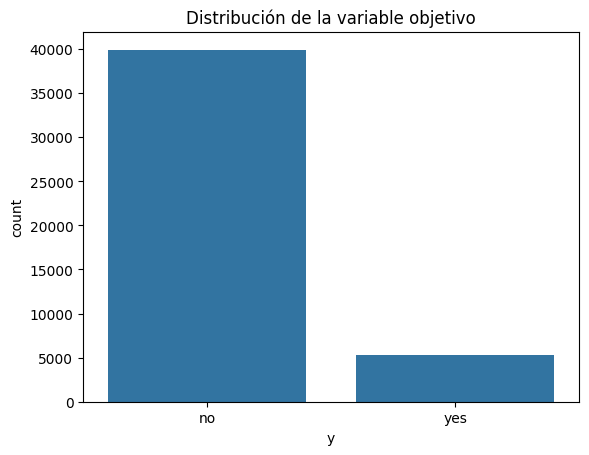

In [198]:
sns.countplot(data=df, x="y")
plt.title("Distribución de la variable objetivo")
plt.show()

La variable objetivo presenta un marcado desbalance entre clases. La mayoría de los registros corresponden a clientes que no aceptaron la campaña de marketing ("no"), mientras que una proporción considerablemente menor corresponde a clientes que sí la aceptaron ("yes"). Debido a este desbalance, además de Accuracy se utilizarán métricas como Precision, Recall y F1-Score para evaluar los modelos.

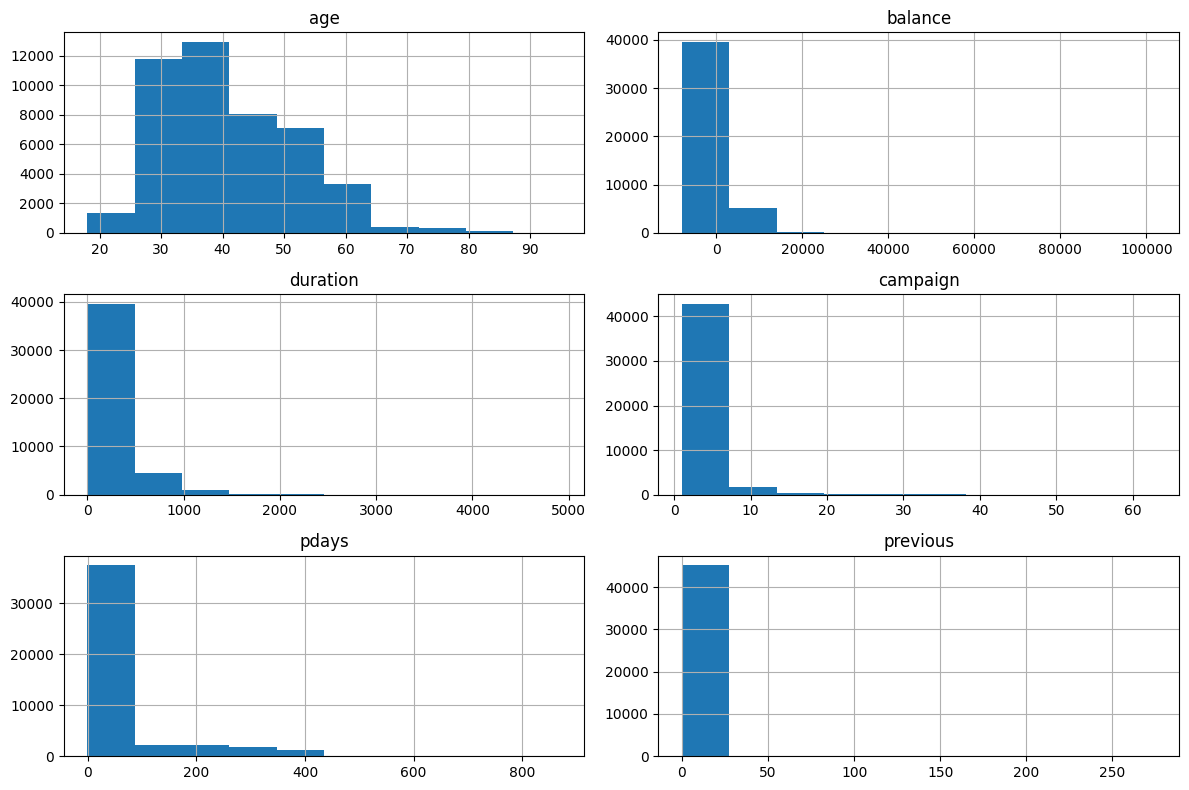

In [199]:
numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

df[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Análisis de las distribuciones

**Age:** La edad presenta una distribución relativamente concentrada entre los 30 y 60 años, observándose algunos casos de edades más avanzadas. La mayoría de los clientes se encuentra en rangos de edad laboral activa.

**Balance:** El saldo bancario muestra una distribución asimétrica hacia la derecha. La mayoría de los clientes posee balances relativamente bajos, mientras que algunos presentan valores significativamente superiores, lo que podría indicar la presencia de valores atípicos.

**Duration:** La duración de las llamadas se concentra en valores bajos, aunque existen llamadas considerablemente más largas. Esto genera una distribución con una cola larga hacia la derecha.

**Campaign:** La cantidad de contactos realizados durante la campaña se concentra principalmente en valores bajos. Solo una pequeña proporción de clientes fue contactada un número elevado de veces.

**Pdays:** La mayoría de los clientes presenta valores bajos en esta variable, indicando que el último contacto registrado ocurrió recientemente o en un período relativamente corto. Sin embargo, existe una cola larga hacia valores más elevados, lo que evidencia la presencia de algunos clientes con períodos considerablemente mayores desde el último contacto.

**Previous:** La distribución se encuentra fuertemente concentrada en valores bajos, indicando que la mayoría de los clientes posee pocos o ningún contacto previo registrado. Solo una pequeña cantidad de casos presenta valores elevados, generando una distribución asimétrica con algunos valores atípicos.

En general, varias de las variables numéricas presentan distribuciones asimétricas y posibles valores extremos, por lo que resulta conveniente complementar este análisis mediante boxplots para identificar potenciales outliers.

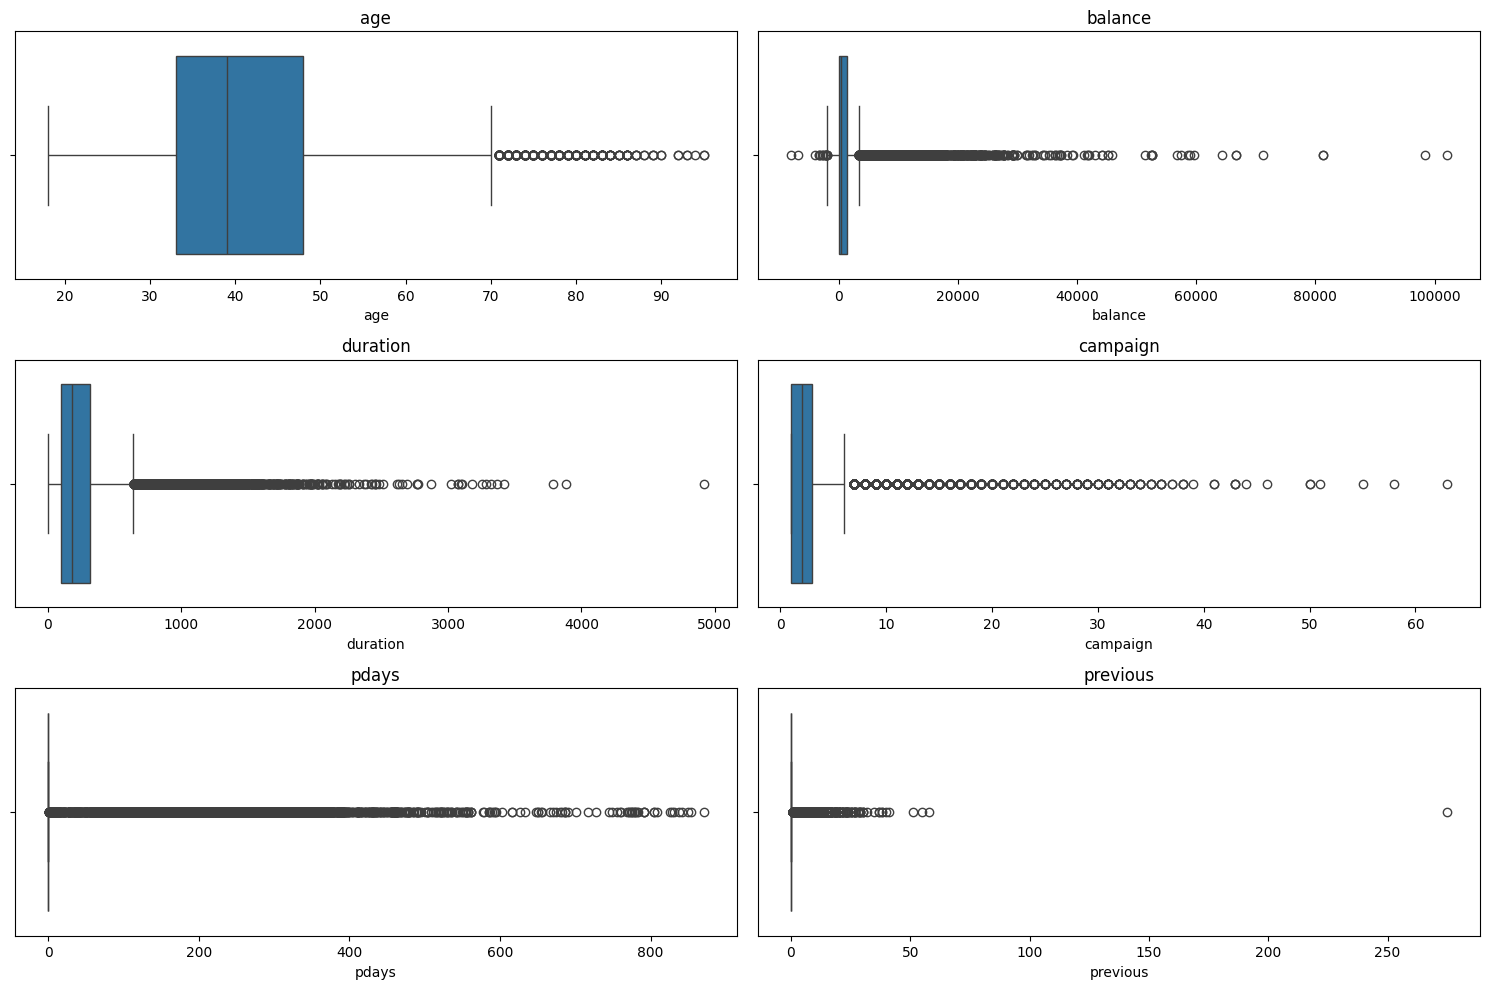

In [200]:
numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Análisis de outliers

Los boxplots permiten identificar la presencia de valores atípicos en varias de las variables numéricas del dataset.

**Age:** Se observan algunos valores extremos correspondientes a clientes de edades avanzadas, aunque la mayoría de los registros se concentra dentro de un rango relativamente acotado.

**Balance:** Presenta una gran cantidad de valores atípicos positivos. Existen clientes con balances significativamente superiores al promedio, lo que genera una fuerte asimetría en la distribución.

**Duration:** Se observan numerosas llamadas con duraciones considerablemente mayores al valor típico, produciendo una importante cantidad de outliers hacia valores altos.

**Campaign:** La mayoría de los clientes fue contactada pocas veces, aunque existen casos particulares donde el número de contactos fue significativamente mayor.

**Pdays:** Presenta una elevada dispersión y una gran cantidad de valores extremos. Esto indica diferencias importantes en la cantidad de días transcurridos desde contactos previos.

**Previous:** La mayoría de los clientes posee pocos contactos previos registrados, aunque existen algunos casos aislados con valores considerablemente superiores.

Si bien se identificaron numerosos valores atípicos, no se consideran errores de carga evidentes sino observaciones reales del comportamiento de los clientes. Por este motivo, inicialmente se conservarán en el dataset y se evaluará el desempeño de los modelos sin eliminarlos. Esta decisión permite preservar información potencialmente relevante para la clasificación.

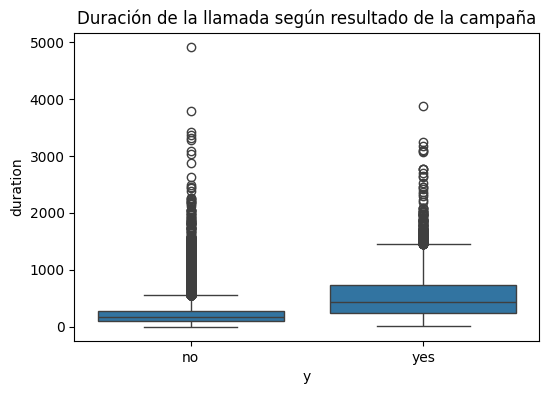

In [201]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='y', y='duration')
plt.title('Duración de la llamada según resultado de la campaña')
plt.show()

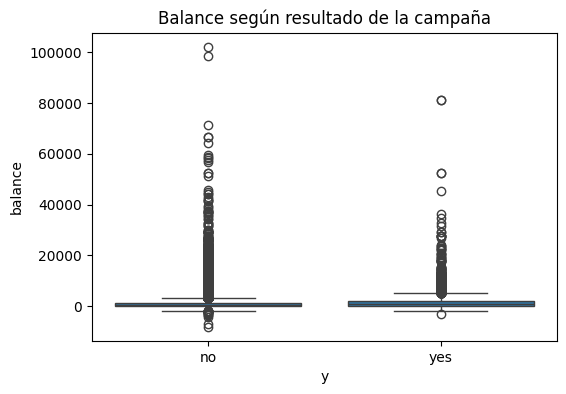

In [202]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='y', y='balance')
plt.title('Balance según resultado de la campaña')
plt.show()

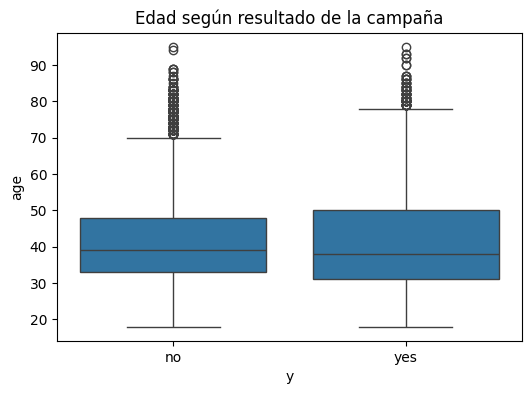

In [203]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='y', y='age')
plt.title('Edad según resultado de la campaña')
plt.show()

### Relación entre variables y la variable objetivo

Se analizaron algunas variables numéricas en función de la variable objetivo para identificar posibles relaciones con la aceptación de la campaña de marketing.

**Duration:** Se observa una diferencia clara entre ambas clases. Los clientes que aceptaron la campaña ("yes") presentan, en general, llamadas de mayor duración que aquellos que no la aceptaron ("no"). Esto sugiere que la duración de la llamada podría ser una variable relevante para la clasificación.

**Balance:** Los clientes que aceptaron la campaña muestran balances ligeramente superiores en comparación con quienes no la aceptaron. Sin embargo, la diferencia es menos marcada que en la variable duración.

**Age:** Las distribuciones de edad son similares entre ambas clases. No se observan diferencias importantes en la mediana, aunque los clientes que aceptaron la campaña presentan una mayor dispersión de edades y una mayor presencia de edades avanzadas.

En conjunto, la variable **duration** parece mostrar la relación más evidente con la variable objetivo, mientras que **balance** y **age** podrían aportar información complementaria para los modelos de clasificación.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

## Resolución:

## Preprocesamiento de datos

Antes de entrenar los modelos de clasificación fue necesario realizar tareas de limpieza y transformación de los datos. Estas incluyen el tratamiento de valores faltantes, la eliminación de variables con información insuficiente, la codificación de variables categóricas y el escalado de variables numéricas. El objetivo es obtener un conjunto de datos adecuado para el entrenamiento y evaluación de los clasificadores.

In [204]:
# Imputación de valores faltantes

df["job"] = df["job"].fillna("unknown")
df["education"] = df["education"].fillna("unknown")
df["contact"] = df["contact"].fillna("unknown")

# Eliminación de variable con exceso de faltantes

df = df.drop(columns=["poutcome"])

### Tratamiento de valores faltantes

Durante el análisis exploratorio se identificaron valores faltantes en las variables **job**, **education**, **contact** y **poutcome**.

Las variables **job**, **education** y **contact** fueron imputadas utilizando la categoría "unknown" con el fin de conservar los registros disponibles y evitar la pérdida de información.

Por otra parte, la variable **poutcome** fue eliminada debido a que más del 80% de sus valores se encontraban ausentes, lo que limita significativamente su utilidad para el modelado.

In [205]:
df.isnull().sum().sort_values(ascending=False)

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day_of_week,0


Luego de la imputación de las variables categóricas y la eliminación de la variable `poutcome`, el dataset ya no presenta valores faltantes, por lo que se encuentra listo para las siguientes etapas de transformación y modelado.

In [206]:
X = df.drop("y", axis=1)

y = df["y"].map({
    "no": 0,
    "yes": 1
})

In [207]:
y.value_counts()

,count
y,
0,39922
1,5289


### Transformación de la variable objetivo

La variable objetivo `y` fue convertida a formato numérico para facilitar el entrenamiento de los modelos de clasificación. Se asignó el valor 0 a la clase "no" y el valor 1 a la clase "yes".

La distribución de clases se mantiene sin modificaciones, observándose un desbalance entre ambas categorías, donde la clase 0 representa la mayoría de los registros.

In [208]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [209]:
print(X.shape)

(45211, 39)


In [210]:
X.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False


### Codificación de variables categóricas

Se decidió utilizar las variables categóricas presentes en el dataset debido a que contienen información potencialmente relevante para la clasificación.

Dado que los algoritmos de Machine Learning no pueden trabajar directamente con variables de texto, se aplicó la técnica One-Hot Encoding mediante la función `get_dummies()` de Pandas. Este procedimiento transforma cada categoría en variables binarias que pueden ser utilizadas por los modelos de clasificación.

Se utilizó el parámetro `drop_first=True` para evitar la generación de variables redundantes y reducir problemas de multicolinealidad.

Luego de esta transformación, el conjunto de variables predictoras pasó a tener 39 características.

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [212]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (36168, 39)
Test: (9043, 39)


### División de datos

El conjunto de datos fue dividido en entrenamiento y prueba utilizando una proporción 80/20.

El conjunto de entrenamiento quedó conformado por 36.168 registros, mientras que el conjunto de prueba contiene 9.043 registros.

Se utilizó el parámetro `stratify=y` para conservar la proporción original de clases en ambos conjuntos, manteniendo el desbalance observado en la variable objetivo y permitiendo una evaluación más representativa del desempeño de los modelos.

In [213]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [214]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(36168, 39)
(9043, 39)


### Escalado de variables

Se aplicó la técnica de estandarización mediante `StandardScaler`, que transforma las variables para que tengan media cercana a 0 y desviación estándar cercana a 1.

Este paso resulta especialmente importante para algoritmos como Logistic Regression y K-Nearest Neighbors (KNN), ya que utilizan coeficientes o distancias sensibles a las diferencias de escala entre variables.

El escalado fue ajustado utilizando únicamente los datos de entrenamiento (`fit_transform`) y posteriormente aplicado al conjunto de prueba (`transform`) para evitar fugas de información (*data leakage*).

### Resumen del preprocesamiento realizado

Durante esta etapa se trataron los valores faltantes mediante imputación y eliminación de variables con excesiva cantidad de datos ausentes. Posteriormente se transformó la variable objetivo a formato numérico y se aplicó One-Hot Encoding sobre las variables categóricas.

El conjunto de datos fue dividido en entrenamiento y prueba utilizando una proporción 80/20, manteniendo la distribución original de clases mediante estratificación. Finalmente, se aplicó estandarización a las variables predictoras para asegurar que todas contribuyan en escalas comparables al entrenamiento de los modelos.

Luego de estas transformaciones, los datos se encuentran preparados para el entrenamiento y evaluación de los clasificadores.




## 4. **Clasificación con logistic regression**  
   

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

### 4.1 Entrenamiento y evaluación

In [215]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [216]:
print(y_pred_lr[:10])

[0 0 0 0 0 0 0 1 0 0]


Se entrenó un modelo de Regresión Logística utilizando los datos previamente preprocesados y escalados. Se configuró un máximo de 1000 iteraciones para asegurar la convergencia del algoritmo.

Una vez entrenado el modelo, se generaron predicciones sobre el conjunto de prueba para evaluar su capacidad de clasificación.

### 4.2 Métricas de evaluación

Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.

In [217]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1 Score:", round(f1,4))

Accuracy: 0.8946
Precision: 0.6096
Recall: 0.276
F1 Score: 0.38


In [218]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.61      0.28      0.38      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.63      0.66      9043
weighted avg       0.88      0.89      0.88      9043



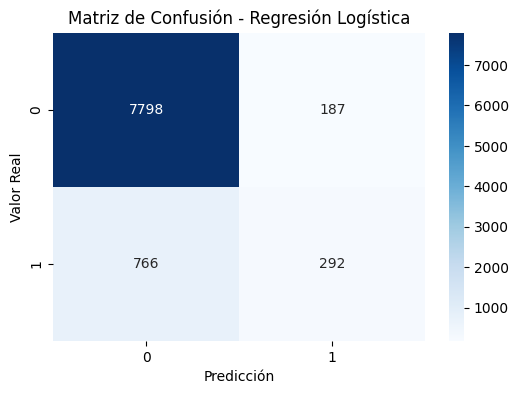

In [219]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

### Interpretación de resultados

El modelo de Regresión Logística obtuvo una Accuracy de 89,46%, lo que inicialmente podría considerarse un buen resultado. Sin embargo, dado que el dataset presenta un importante desbalance entre clases, resulta necesario analizar métricas adicionales.

La Precision alcanzó un valor de 60,96%, indicando que aproximadamente seis de cada diez clientes clasificados como potenciales aceptantes de la campaña efectivamente pertenecen a esa categoría.

Por otro lado, el Recall fue de 27,6%, lo que indica que el modelo solo logra identificar una parte reducida de los clientes que realmente aceptaron la campaña. Esto puede observarse también en la matriz de confusión, donde se registran 766 falsos negativos.

El F1-Score obtenido fue de 0,38, reflejando el compromiso entre Precision y Recall.

En conjunto, el modelo presenta una buena capacidad para identificar la clase mayoritaria ("no"), pero muestra dificultades para detectar correctamente a los clientes que aceptan la campaña ("yes"), probablemente debido al desbalance presente en el dataset.

## 5- **Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

### Selección del segundo clasificador

Para complementar el análisis realizado con Regresión Logística, se seleccionó el algoritmo K-Nearest Neighbors (KNN).

Este modelo clasifica nuevas observaciones considerando las clases de los vecinos más cercanos en el espacio de características. Además, resulta adecuado para comparar enfoques diferentes de clasificación, ya que mientras la Regresión Logística genera una frontera de decisión lineal, KNN basa sus predicciones en la proximidad entre observaciones.

Se utilizarán los parámetros por defecto de la implementación de sklearn, tal como solicita la consigna.

### 5.2 Entrenamiento del modelo.

In [220]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

### 5.3 Evaluación del desempeño

In [221]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy:", round(accuracy_knn,4))
print("Precision:", round(precision_knn,4))
print("Recall:", round(recall_knn,4))
print("F1:", round(f1_knn,4))

Accuracy: 0.8859
Precision: 0.5261
Recall: 0.2476
F1: 0.3368


In [222]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.53      0.25      0.34      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.61      0.64      9043
weighted avg       0.86      0.89      0.87      9043



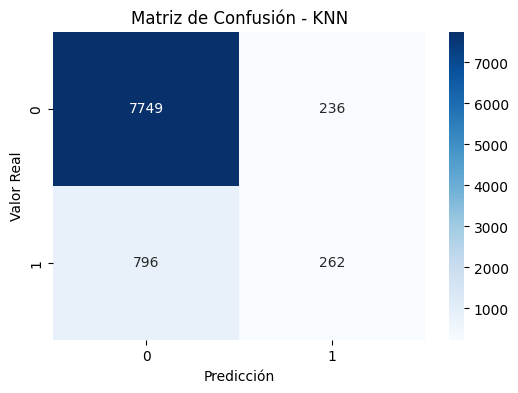

In [223]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

### Interpretación de resultados

El modelo K-Nearest Neighbors obtuvo una Accuracy de 88,59%, un valor ligeramente inferior al alcanzado por la Regresión Logística.

La Precision fue de 52,61%, indicando que aproximadamente la mitad de los clientes clasificados como potenciales aceptantes de la campaña efectivamente pertenecen a dicha categoría.

El Recall alcanzó un valor de 24,76%, evidenciando dificultades para identificar correctamente a los clientes que aceptaron la campaña. Este comportamiento también puede observarse en la matriz de confusión, donde se registran 796 falsos negativos.

El F1-Score obtenido fue de 0,3368, reflejando un desempeño inferior al observado en la Regresión Logística.

En general, KNN mostró un rendimiento aceptable sobre la clase mayoritaria, pero presentó mayores dificultades que la Regresión Logística para detectar clientes pertenecientes a la clase positiva.

## 6  Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.

En el punto anterior se utilizó KNN con los parámetros por defecto de sklearn, donde n_neighbors=5. En esta sección se evaluará cómo afecta la modificación de este hiperparámetro al desempeño del modelo.

In [224]:
k_values = [3, 5, 7, 9, 11, 15, 21]

resultados_knn = []

for k in k_values:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train_scaled, y_train)
    y_pred = modelo_knn.predict(X_test_scaled)

    resultados_knn.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

df_resultados_knn = pd.DataFrame(resultados_knn)
df_resultados_knn

,k,Accuracy,Precision,Recall,F1
0,3,0.883888,0.506536,0.293006,0.371257
1,5,0.885879,0.526104,0.247637,0.336761
2,7,0.887758,0.547884,0.232514,0.326476
3,9,0.889638,0.570093,0.230624,0.328398
4,11,0.891297,0.598425,0.215501,0.316887
5,15,0.890302,0.591160,0.202268,0.301408
6,21,0.890634,0.608150,0.183365,0.281772


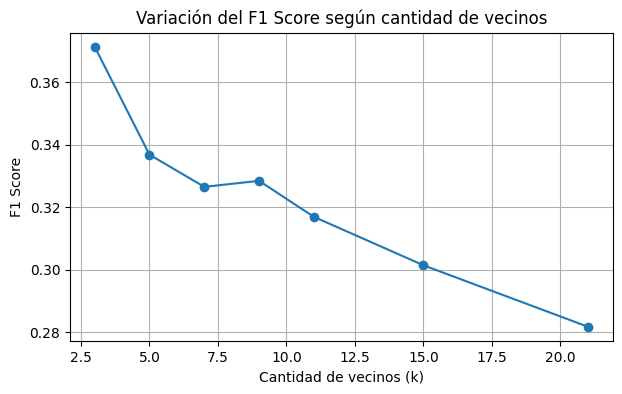

In [225]:
plt.figure(figsize=(7,4))
plt.plot(df_resultados_knn["k"], df_resultados_knn["F1"], marker="o")
plt.title("Variación del F1 Score según cantidad de vecinos")
plt.xlabel("Cantidad de vecinos (k)")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

### Interpretación del tuneo

Se evaluaron distintos valores del hiperparámetro `n_neighbors` para analizar su impacto en el desempeño del modelo KNN.

El mejor resultado según F1-Score se obtuvo con `k=3`, alcanzando un valor de 0.3713. Este resultado mejora el F1 obtenido con el valor por defecto de sklearn (`k=5`), que había sido de 0.3368.

A medida que aumenta la cantidad de vecinos, la Accuracy tiende a mantenerse estable o aumentar levemente, pero el Recall disminuye. Esto indica que el modelo se vuelve más conservador para predecir la clase positiva (`yes`), dejando de identificar una mayor cantidad de clientes que realmente aceptaron la campaña.

Dado que el dataset se encuentra desbalanceado, se considera más adecuado observar el F1-Score y el Recall además de la Accuracy. Por este motivo, dentro de los valores evaluados, `k=3` resultó ser la mejor configuración para KNN.

## 6- Conclusiones



En este trabajo se abordó un problema de clasificación binaria utilizando el dataset Bank Marketing del repositorio UCI. El objetivo consistió en predecir si un cliente aceptaría o no una campaña de marketing para la contratación de un depósito a plazo fijo.

Durante el análisis exploratorio se identificaron valores faltantes, variables categóricas y un importante desbalance entre las clases de la variable objetivo. Estas características hicieron necesario realizar tareas de preprocesamiento, incluyendo imputación de valores faltantes, codificación mediante One-Hot Encoding, división de datos en entrenamiento y prueba, y estandarización de variables.

Se entrenaron dos modelos de clasificación: Regresión Logística y K-Nearest Neighbors (KNN). Ambos obtuvieron valores de Accuracy cercanos al 89%, aunque el análisis de métricas adicionales mostró diferencias relevantes debido al desbalance presente en el dataset.

La Regresión Logística obtuvo los mejores resultados generales, alcanzando una Accuracy de 89,46%, una Precision de 60,96%, un Recall de 27,60% y un F1-Score de 0,38. Por su parte, KNN presentó un desempeño ligeramente inferior, especialmente en Recall y F1-Score.

Posteriormente se realizó un proceso de ajuste del hiperparámetro `n_neighbors` en KNN. El mejor resultado se obtuvo con `k=3`, logrando mejorar el F1-Score respecto a la configuración por defecto. Sin embargo, incluso con esta mejora, el desempeño continuó siendo levemente inferior al de la Regresión Logística.

Considerando únicamente las secciones obligatorias del trabajo, la Regresión Logística obtuvo el mejor desempeño general, alcanzando los valores más altos de Accuracy, Precision y F1-Score entre los modelos evaluados.

Sin embargo, al aplicar la técnica SMOTE en el Bonus 2, el modelo KNN logró una mejora significativa en Recall y F1-Score, obteniendo el mejor equilibrio para detectar clientes que aceptaron la campaña. Esto demuestra la importancia de tratar el desbalance de clases en problemas de clasificación como el presente.

Por este motivo, considerando tanto las secciones obligatorias como el experimento adicional realizado en el Bonus 2, KNN + SMOTE se presenta como la alternativa más adecuada para este problema.


# Referencias

-UCI Machine Learning Repository. Bank Marketing Dataset. https://archive.ics.uci.edu/dataset/222/bank+marketing

-Scikit-learn Documentation. Logistic Regression.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

-Scikit-learn Documentation. KNeighborsClassifier.
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

-Pandas Documentation.
https://pandas.pydata.org/docs/

-Material teórico y notebooks de la materia Aprendizaje Automático 1.

# BONUS 1

Si su dataset estaba relativamente balanceado, como bonus pruebe entrenar otro modelo clasificador diferente y comparar resultados con su clasificador elegido en 5) y el modelo elegido 6) luego del tuneo de hiperparámetros.



# BONUS 2

Si su dataset estaba desbalanceado, puebe utilizar alguna técnica para lidiar con el desbalance de clases durante el entrenamiento.

1) Ofrezca una comparativa de entrenar y evaluar modelos de Logistic regression con y sin class_weight='balanced' o el modelo SVC con y sin class_weight='balanced'

2) Pruebe entrenar KNN con y sin uso de SMOTE

( Ver apunte sobre Desbalance de clases de la cátedra )



# Bonus 2 - Tratamiento del desbalance de clases

La consigna propone dos alternativas para abordar el problema de desbalance de clases:

1. Comparar modelos de Regresión Logística o SVC con y sin el parámetro `class_weight='balanced'`.
2. Comparar KNN con y sin la aplicación de la técnica SMOTE.

En este trabajo se optó por desarrollar la segunda alternativa, entrenando y evaluando el modelo KNN antes y después de aplicar SMOTE sobre el conjunto de entrenamiento, con el objetivo de analizar el impacto del balanceo de clases en las métricas de desempeño.

In [226]:
!pip install imbalanced-learn -q

In [227]:
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Distribución original:")
print(y_train.value_counts())

print("\nDistribución luego de SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Distribución original:
y
0    31937
1     4231
Name: count, dtype: int64

Distribución luego de SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


### Aplicación de SMOTE

Dado que el dataset presenta un importante desbalance entre clases, se aplicó la técnica SMOTE (Synthetic Minority Oversampling Technique) sobre el conjunto de entrenamiento.

SMOTE genera ejemplos sintéticos de la clase minoritaria a partir de sus vecinos más cercanos, permitiendo equilibrar la distribución de clases sin simplemente duplicar registros existentes.

Es importante destacar que SMOTE fue aplicado únicamente sobre el conjunto de entrenamiento, manteniendo el conjunto de prueba sin modificaciones para realizar una evaluación representativa del problema real.

In [228]:
from sklearn.neighbors import KNeighborsClassifier

knn_smote = KNeighborsClassifier(
    n_neighbors=3
)

knn_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = knn_smote.predict(X_test_scaled)

In [229]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", round(accuracy_score(y_test, y_pred_smote),4))
print("Precision:", round(precision_score(y_test, y_pred_smote),4))
print("Recall:", round(recall_score(y_test, y_pred_smote),4))
print("F1:", round(f1_score(y_test, y_pred_smote),4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.8466
Precision: 0.3979
Recall: 0.6059
F1: 0.4803

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      7985
           1       0.40      0.61      0.48      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.74      0.70      9043
weighted avg       0.88      0.85      0.86      9043



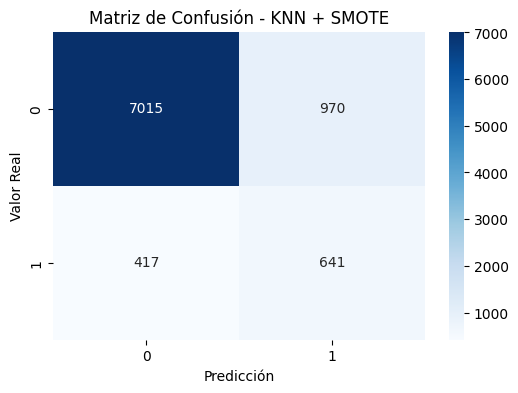

In [230]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - KNN + SMOTE")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

### Interpretación de resultados

La aplicación de SMOTE generó cambios importantes en el desempeño del modelo KNN previamente optimizado (k=3). Al equilibrar las clases del conjunto de entrenamiento, el modelo logró mejorar notablemente su capacidad para identificar clientes que aceptaron la campaña de marketing.

Si bien la Accuracy disminuyó de 88,39% a 84,66% y la Precision también se redujo, el Recall aumentó significativamente, pasando de 29,30% a 60,59%. Esto significa que el modelo logró detectar una proporción mucho mayor de casos positivos reales, reduciendo considerablemente la cantidad de clientes interesados que no eran identificados por el clasificador.

Como contrapartida, el incremento en Recall produjo un aumento en la cantidad de falsos positivos, comportamiento habitual cuando se prioriza la detección de la clase minoritaria en problemas desbalanceados.

El F1-Score pasó de 0,3713 a 0,4803, obteniendo el mejor resultado de todo el trabajo. Dado que esta métrica combina Precision y Recall, su mejora indica que el balance general del modelo resultó más adecuado para este problema de clasificación.

En conclusión, la aplicación de SMOTE permitió mejorar significativamente la detección de la clase positiva, demostrando que el tratamiento del desbalance de clases puede tener un impacto más relevante en el desempeño del modelo que el ajuste de hiperparámetros por sí solo.


In [231]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "KNN (k=3)",
        "KNN + SMOTE (k=3)"
    ],
    "Accuracy": [
        0.8946,
        0.8839,
        0.8466
    ],
    "Precision": [
        0.6096,
        0.5065,
        0.3979
    ],
    "Recall": [
        0.2760,
        0.2930,
        0.6059
    ],
    "F1 Score": [
        0.3800,
        0.3713,
        0.4803
    ]
})

comparacion

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8946,0.6096,0.2760,0.3800
1,KNN (k=3),0.8839,0.5065,0.2930,0.3713
2,KNN + SMOTE (k=3),0.8466,0.3979,0.6059,0.4803


### Comparación final de modelos

Al comparar todos los modelos evaluados, se observa que la Regresión Logística obtuvo la mayor Accuracy y Precision. Sin embargo, el modelo KNN con SMOTE alcanzó el mejor Recall y el mayor F1-Score, logrando identificar una proporción significativamente mayor de clientes que aceptaron la campaña.

Dado que el dataset presenta un importante desbalance entre clases y que el objetivo del problema consiste en detectar clientes potencialmente interesados en la campaña, el modelo KNN con SMOTE resulta la alternativa más equilibrada entre capacidad predictiva y detección de la clase positiva.

Por este motivo, se selecciona KNN con SMOTE como modelo final para este problema.